In [3]:
import KNN
import pandas as pd
df = pd.read_csv('Iris.csv')
print(f"Размер датасета: {df.shape}")
df.info()
df.isnull().sum()
display(df['Species'].value_counts())
df.describe()


Размер датасета: (150, 6)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


* Размер датасета: (150, 6)
* Типы признаков: 4 числовых и 1 категориальный
* Пропусков нет
* Классы распределены поровну по 50
* Возможные проблемы: за признак будет считаться поле id, что является неинформативным полем; проблема с масштабированием и признаки с большими значениями будут оказывать избыточное влияние на расстояние


In [10]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
X = df.drop(['Id', 'Species'], axis = 1)
labelencoder = LabelEncoder()
y = labelencoder.fit_transform(df['Species'])
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.67, random_state=42)
scaler = MinMaxScaler(feature_range=(0,1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Подбор параметров на тестовой выборке недопустим, так как это ведет к переобучению под конкретный набор данных и потере обобщающей способности модели. Масштабирование важно для KNN, тк признаки с большими значениями будут оказывать избыточное влияние на расстояние

In [5]:
from matplotlib.colors import ListedColormap
import numpy as np

def plot_decision_boundaries(X, y, model, ax=None, title="Decision Boundaries"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Определяем границы графика с небольшим запасом
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Создаем сетку точек для построения границы
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Предсказываем класс для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Определяем цветовую схему
    colors = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

    # Отображаем границы решения
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=colors)

    # Отображаем обучающие точки
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=80, edgecolor='k', cmap=colors)

    # Добавляем легенду
    legend1 = ax.legend(*scatter.legend_elements(), title="Классы")
    ax.add_artist(legend1)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

    return ax

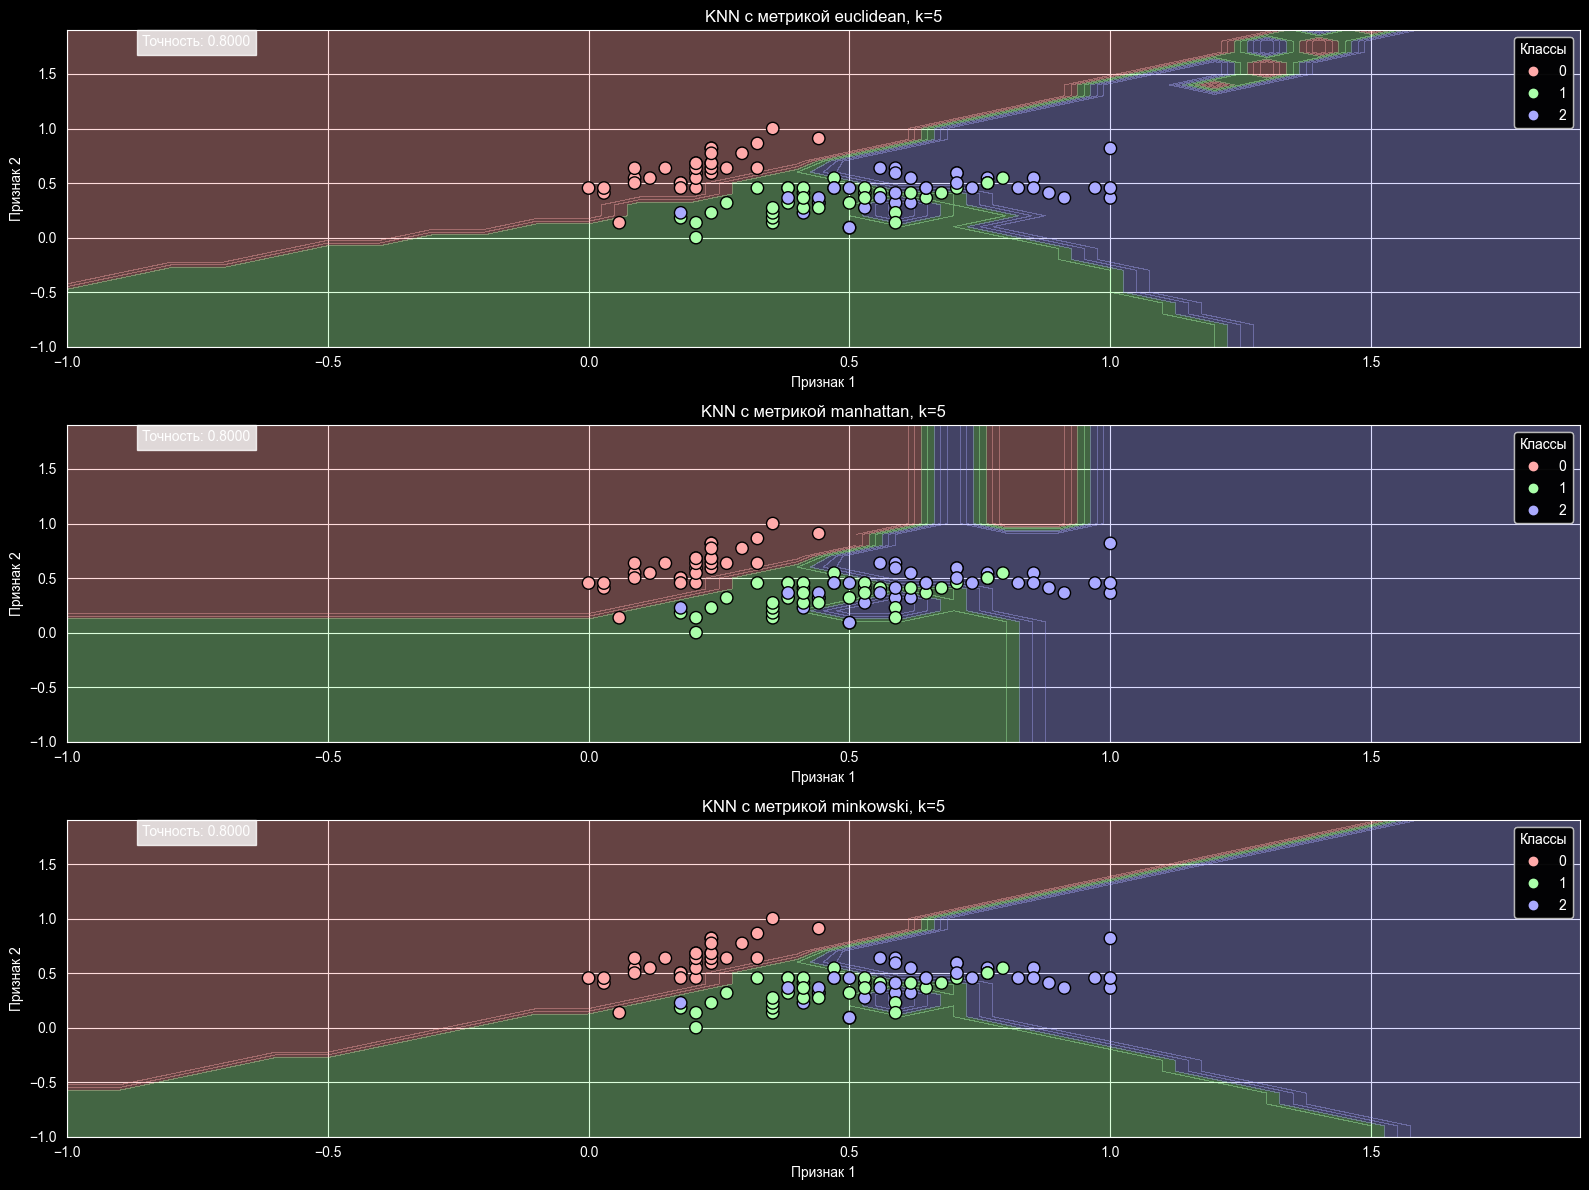

In [34]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
metrics = ['euclidean', 'manhattan', 'minkowski']
k = 5
features = ['PetalLengthCm', 'PetalWidthCm']
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    X_train_sub = X_train_scaled[:, [2, 3]]
    X_test_sub = X_test_scaled[:, [2, 3]]
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=(3 if metric == 'minkowski' else 2))
    knn.fit(X_train_sub, y_train)
    plot_decision_boundaries(X_train_sub, y_train, knn, ax=axes[i],
                            title=f'KNN с метрикой {metric}, k={k}')

    accuracy = knn.score(X_test_sub, y_test)
    axes[i].text(0.05, 0.95, f'Точность: {accuracy:.4f}', transform=axes[i].transAxes,
                 bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Построив графики для двух признаков: длтна и ширина лепестков, можем увидеть, что несмотря на одинаковую точность, форма границ различается. По графику метрика Minkowski дает самые сглаженные границы.

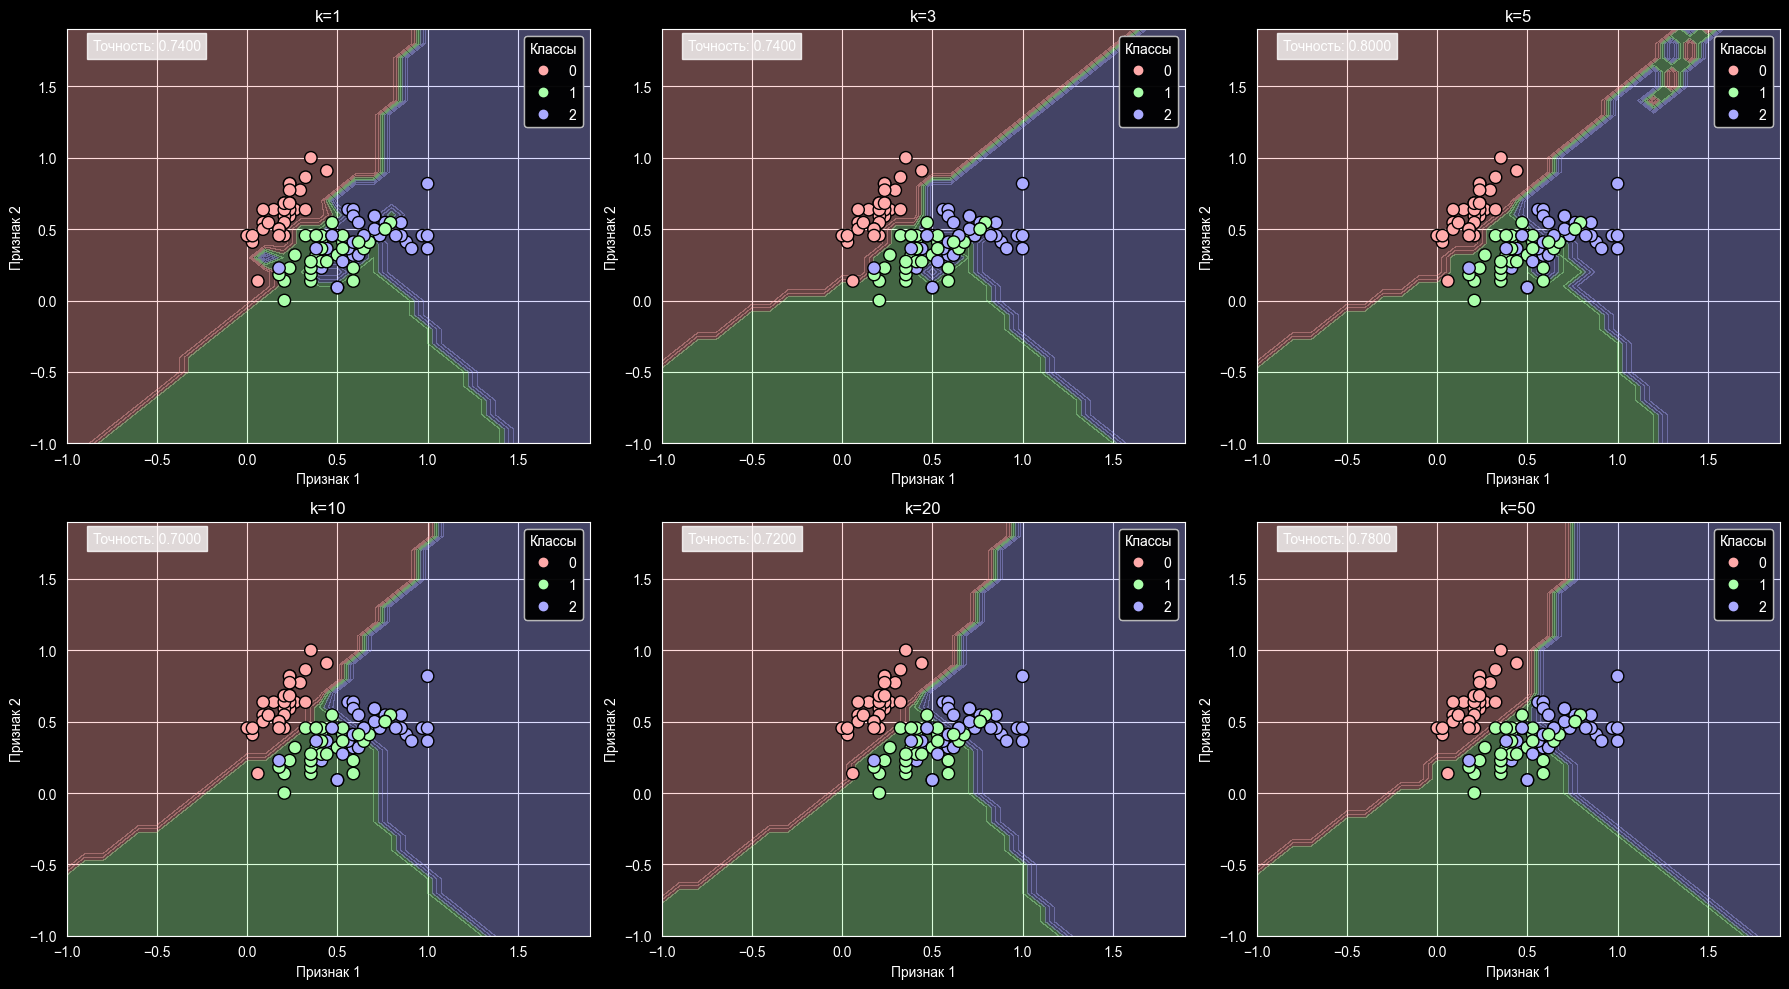

In [21]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
metric = 'euclidean'
k = [1, 3, 5, 10, 20, 50]
features = ['SepalLengthCm', 'SepalWidthCm']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, k in enumerate(k):
    X_train_sub = X_train_scaled[:, [0, 1]]
    X_test_sub = X_test_scaled[:, [0, 1]]
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=(3 if metric == 'minkowski' else 2))
    knn.fit(X_train_sub, y_train)
    plot_decision_boundaries(X_train_sub, y_train, knn, ax=axes[i],
                            title=f'k={k}')

    accuracy = knn.score(X_test_sub, y_test)
    axes[i].text(0.05, 0.95, f'Точность: {accuracy:.4f}', transform=axes[i].transAxes,
                 bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

На этом графике мы взяли длину и ширину чашелистиков. С увеличением числа соседей линии становятся более гладкими. Однако при малых значениях модель переобучена, а при больших недообучена, поэтому стоит выбирать что-то среднее(например, на графике максимальная точность достигается, когда k = 5)

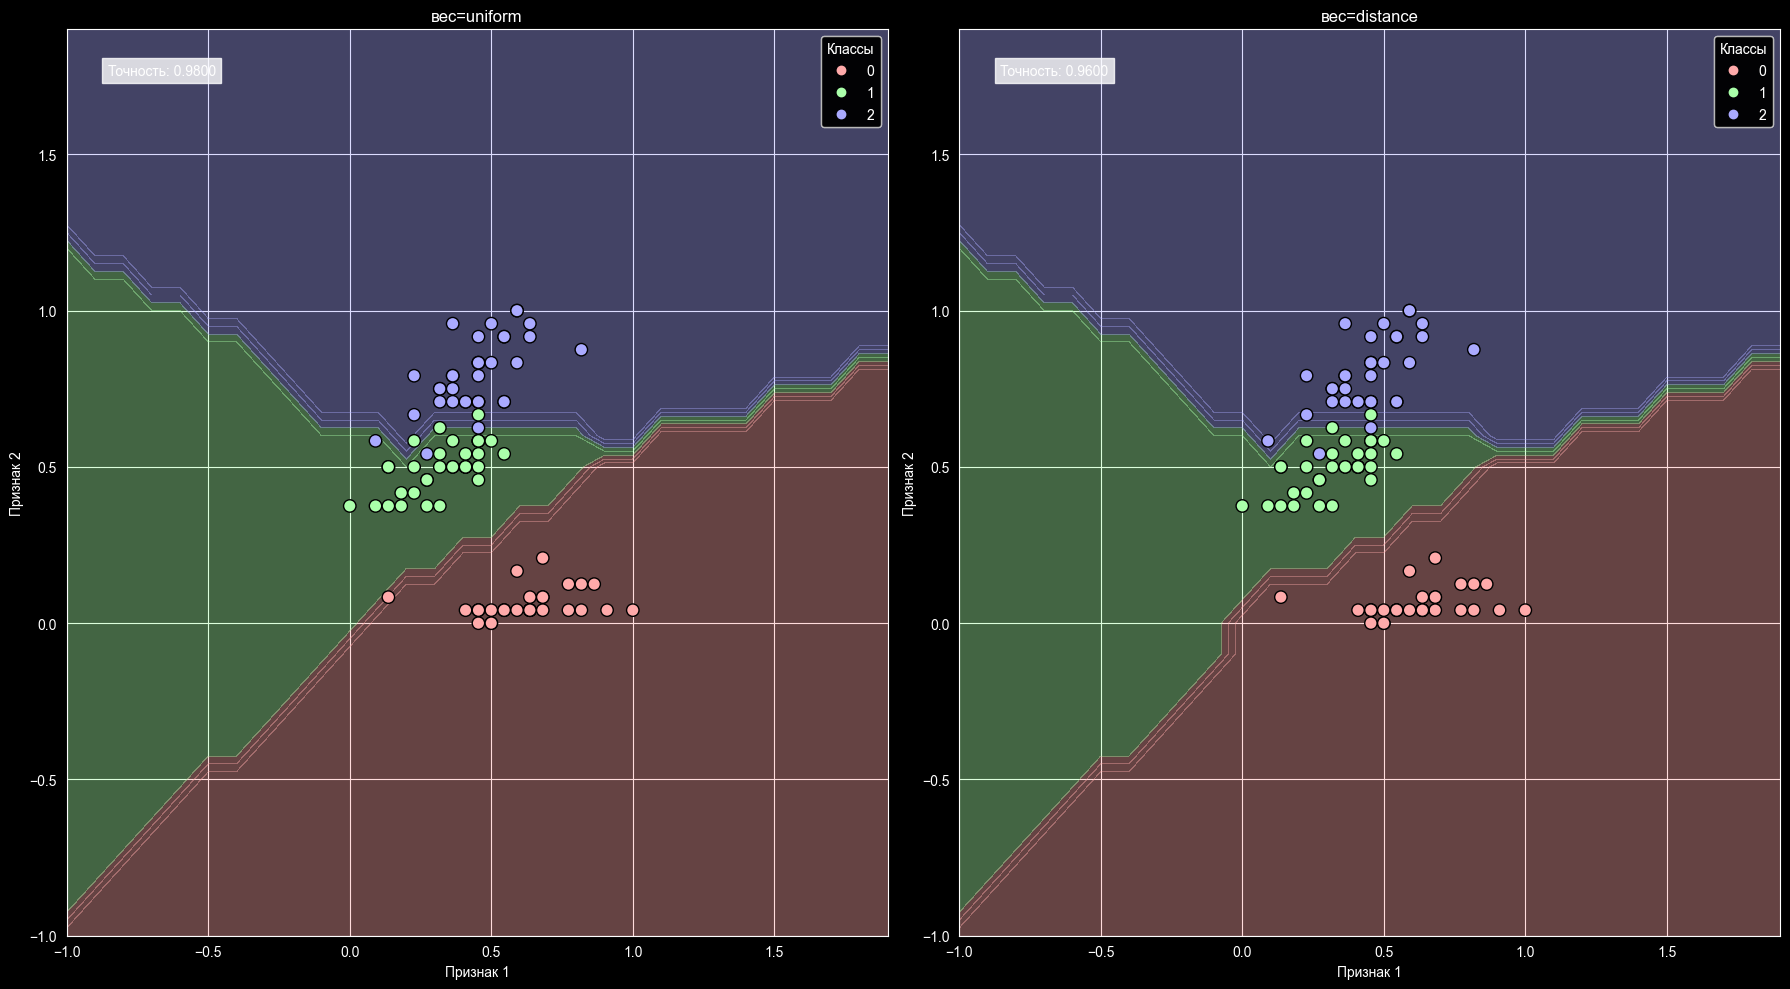

In [26]:
weights_options = ['uniform', 'distance']
metric = 'euclidean'
features = ['SepalLengthCm', 'SepalWidthCm']
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
axes = axes.flatten()

for i, weights in enumerate(weights_options):
    X_train_sub = X_train_scaled[:, [1, 3]]
    X_test_sub = X_test_scaled[:, [1, 3]]
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=(3 if metric == 'minkowski' else 2), weights = weights)
    knn.fit(X_train_sub, y_train)
    plot_decision_boundaries(X_train_sub, y_train, knn, ax=axes[i],
                            title=f'вес={weights}')

    accuracy = knn.score(X_test_sub, y_test)
    axes[i].text(0.05, 0.95, f'Точность: {accuracy:.4f}', transform=axes[i].transAxes,
                 bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

На этом графике длина лепестков и чашелистиков. Режим uniform дает более обобщенные и сглаженные границы.Режим distance делает границы более сложными и чувствительными к расположению каждой точки.
Исходя из всех графиков можно сделать вывод,что метрика Minkowski, k = 5  и вес uniform лучшие параметры, однако следует учесть, что график рисует только 2д модель, а признаков у нас 4, поэтому результаты могут быть не совсем точные

In [30]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print(f"Точность на каждом фолде: {scores}")
print(f"Средняя точность: {scores.mean():.4f}")
print(f"Разброс: {scores.std():.4f}")



Точность на каждом фолде: [0.95 0.85 0.9  1.   0.95]
Средняя точность: 0.9300
Разброс: 0.0510


Точность на каждом из 5 фолдов варьируется незначительно, что подтверждает отсутствие переобучения  и хорошую обобщающую способность модели.

In [55]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 10, 15, 20, 30, 50],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
print(f"Самые удачные параметры: {grid_search.best_params_}")

Самые удачные параметры: {'metric': 'euclidean', 'n_neighbors': 50, 'weights': 'distance'}


Выбор Евклидовой метрики обусловлен тем, что все признаки ирисов измеряются в одних единицах. В таком случае расстояние по прямой лучше всего отражает реальное сходство объектов.Параметры, подобранные через GridSearchCV на полном наборе данных (4 признака), являются более точными, чем те, что мы видим на графиках, тк учитывает все данные и может в полной мере оценить всю картину.

In [56]:
from sklearn.metrics import precision_score
metric = 'euclidean'
k = [1, 3, 5, 10, 20, 50]

for i, k in enumerate(k):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=(3 if metric == 'minkowski' else 2))
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = knn.score(X_test_scaled, y_test)
    precision = precision_score(y_test, y_pred, average='macro')

    print( f'Precision: {precision:.4f}')


Precision: 0.9792
Precision: 0.9792
Precision: 0.9792
Precision: 0.9792
Precision: 0.9608
Precision: 0.9174


In [51]:
from sklearn.metrics import precision_score
from sklearn.neighbors import KNeighborsClassifier
metric = 'euclidean'
k = [1, 3, 5, 10, 20, 50]

for i, k in enumerate(k):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=(3 if metric == 'minkowski' else 2))
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = knn.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average='macro')
    print( f'Точность: {accuracy:.4f}')
    print( f'Precision: {precision:.4f}')


Precision: 0.9792
Precision: 0.9792
Precision: 0.9792
Precision: 0.9792
Precision: 1.0000
Precision: 0.9298


In [44]:

metrics = ['euclidean', 'manhattan', 'minkowski']
k = 5

for i, metric in enumerate(metrics):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=(3 if metric == 'minkowski' else 2))
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)
    print( f'Точность: {accuracy:.4f}')


Точность: 0.9800
Точность: 0.9800
Точность: 0.9800


In [57]:
weights_options = ['uniform', 'distance']
metric = 'euclidean'


for i, weights in enumerate(weights_options):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=(3 if metric == 'minkowski' else 2), weights = weights)
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)
    print( f'Точность: {accuracy:.4f}')

Точность: 0.9200
Точность: 0.9800


Здесь мы проверили точность уже на 4 признаках и можем увидеть, что результаты не совсем сходятся с теми, что показал GridSearchCV.В отличие от ручного перебора на одной тестовой выборке, автоматический поиск минимизирует риск случайного успеха и переобучения, выбирая параметры, которые лучше работают на всем объеме данных.Главный минус KNN — он не создает общих правил, а просто запоминает данные. Из-за этого модель чувствительна к качеству выборки: если на границе классов окажется ошибочная точка , алгоритм может неверно разметить целую область.